# Spatial Wavelet Coefficient Transformation through Matrix Multiplication
February 15, 2024

First, let's see if we can compress a 1D vector using a spatial wavelet. Then reconstruct the vector with the reverse transformation.

Then we will try it with a 2D matrix. This will be more involved, but it should be doable as well, as it is multiple passes through the rows and vectors with the hi and lo pass filters.


In [5]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [22]:
import numpy as np
import pywt

In [166]:
def create_downsampling_matrix(n, factor=2):
    """
    Create a downsampling matrix to downsample a signal by a given factor.
    """
    # Number of rows in the downsampling matrix
    rows = n // factor + (n % factor > 0)
    # Initialize the downsampling matrix with zeros
    down_matrix = np.zeros((rows, n))
    
    # Fill the matrix
    for i in range(rows):
        down_matrix[i, i * factor] = 1
    
    return down_matrix


In [173]:
import numpy as np

def create_convolution_matrix(kernel, n):
    """Convert a kernel to a convolution matrix, so when applied with
    a signal of length n, computes a convolution between the kernel and input"""
    k = len(kernel)
    # Output length of the convolution
    output_length = n + k - 2
    
    # Initialize the convolution matrix with zeros
    conv_matrix = np.zeros((output_length, n))
    
    # Fill in the convolution matrix
    for i in range(output_length):
        for j in range(k):
            if 0 <= i - j < n:
                conv_matrix[i, i - j] = kernel[j]
                
    return conv_matrix


In [174]:
def create_upsampling_matrix(n, factor=2):
    """
    Create an upsampling matrix to upsample a signal by a given factor.
    
    Parameters:
    - n: Length of the original signal.
    - factor: Upsampling factor.
    
    Returns:
    - A matrix that upsamples by the given factor when multiplied by a signal vector.
    """
    # Number of columns in the upsampling matrix (length of the upsampled signal)
    cols = n * factor
    # Initialize the upsampling matrix with zeros
    up_matrix = np.zeros((n, cols))
    
    # Fill the matrix
    for i in range(n):
        up_matrix[i, i * factor] = 1
    
    return up_matrix


In [168]:
# Obtain filters
dec_lo, dec_hi = wavelet.dec_lo, wavelet.dec_hi
rec_lo, rec_hi = wavelet.rec_lo, wavelet.rec_hi

In [175]:
up_mat = create_upsampling_matrix(len(signal)//2, 2)
up_mat.shape

(64, 128)

In [180]:
# Sample signal
signal = np.sin(np.linspace(0, 8 * np.pi, 128)) + 0.5 * np.random.randn(128)

# Wavelet selection
wavelet = pywt.Wavelet('db1')

# Create matrices that will decompose and downsample
down_matrix = create_downsampling_matrix(len(signal), 2)
dec_hi_conv_mat = create_convolution_matrix(dec_hi, len(signal))
dec_lo_conv_mat = create_convolution_matrix(dec_lo, len(signal))
down_lo_mat = np.matmul(down_matrix, dec_lo_conv_mat)
down_hi_mat = np.matmul(down_matrix, dec_hi_conv_mat)

# Create matrices that will upsample and reconstruct

# Decomposition
approximation = np.matmul(down_lo_mat, signal)
detail = np.matmul(down_hi_mat, signal)

# Reconstruction
reconstructed_approximation = upsample_apply_filter(approximation, rec_lo)
reconstructed_detail = upsample_apply_filter(detail, rec_hi)

# Combine
reconstructed_signal = reconstructed_approximation + reconstructed_detail


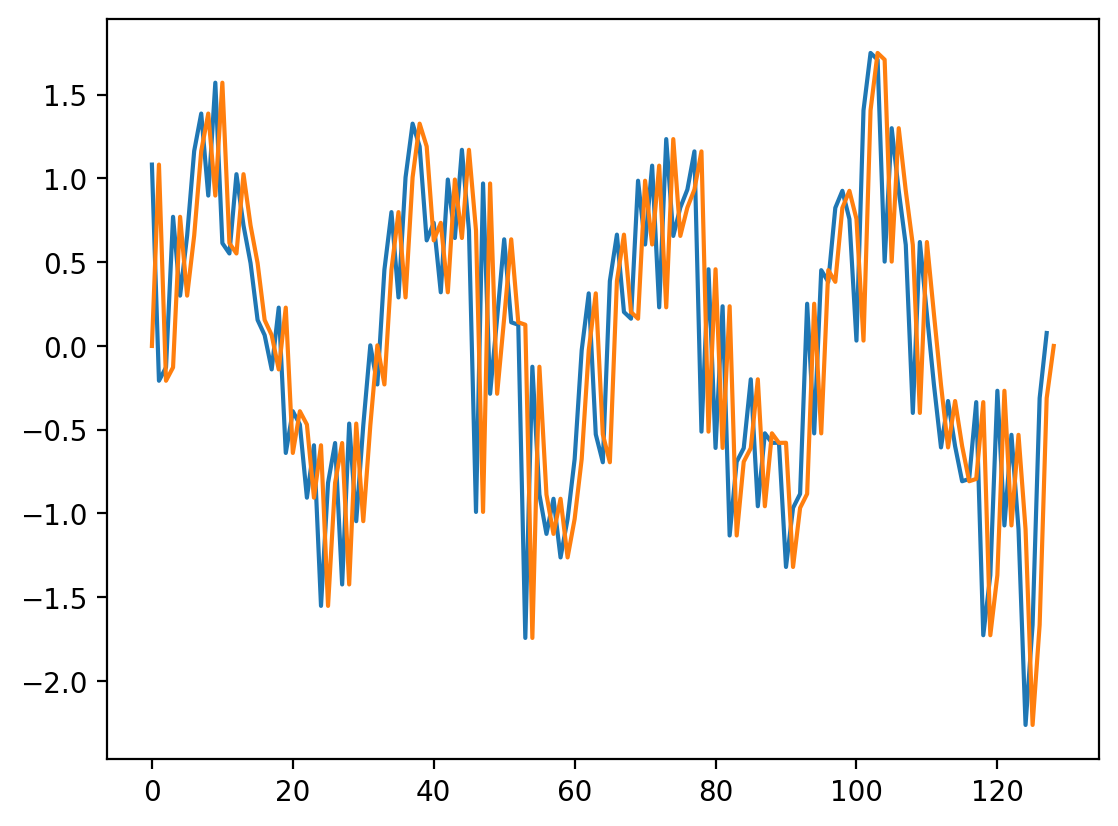

In [181]:
plt.plot(signal)
plt.plot(reconstructed_signal)

Before moving on the 2D, it is worth seeing if it is possible to perform these operations within cvxpy

Input:
- Signal
- Hi deconstruction filter
- Low deconstruction filter
- Hi reconstruction filter
- Low reconstruction filter

### Process:
Take the signal as input, perform deconstruction, threshold, and reconstruction. Can we optimize to minimize the difference between the signal and the reconstruction. The idea may be trivial, but the point is to check if we can perform these deconstruction and reconstruction operations within an optimization objective.

### Notes:
- Variable setting is done with constraints
    - This will be important when we create variables for the upsampling and convolution results.
    - For downsampling, the cvxpy.convolve works when the input signal is constant. However, for 2D images we will eventually need this convolve function to accept a variable input.
    - For upsampling, we need an upsampled array that contains the input signal with zeros.
- We will need to generalize the convolve function


In [132]:
len(signal), len(lo_conv_mat)

(128, 128)

(64, 128)

In [133]:
import cvxpy

def apply_filter_downsample_cvxpy(signal, filter_coeffs):
    filtered = cvxpy.convolve(signal, filter_coeffs)[1::2]
    return filtered

def upsample_apply_filter_cvxpy(constraints, reconstructed, upsampled, signal, 
    filter_coeffs, conv_length):

    # Manually compute convolution (basic method, can be optimized)
    for i in range(conv_length):
        sum_products = 0
        for j in range(len(filter_coeffs)):
            if 0 <= i-j < upsampled_length:
                sum_products += filter_coeffs[j] * upsampled[i-j]

        # Set the convolution result at position i to the sum of products
        constraints.append(reconstructed[i] == sum_products)

n = len(signal)
conv_length = len(signal)
upsampled = cvxpy.Variable((n * 2))
reconstructed = cvxpy.Variable(conv_length)

approximation = apply_filter_downsample_cvxpy(signal, dec_lo)
detail = apply_filter_downsample_cvxpy(signal, dec_hi)

constraints = []

upsample_apply_filter_cvxpy(constraints, reconstructed, upsampled, 
    detail, rec_hi, conv_length)

objective = cvxpy.Minimize(

    # the sum of squares between the input and reconstructed signal
    cvxpy.sum_squares( signal - reconstructed ) +
    cvxpy.sum(approximation + detail) +
    cvxpy.sum(reconstructed)
)

# -------- End definition of the optimization ------------

# Perform the convex optimization
prob = cvxpy.Problem(objective, constraints)

# The epsilon value affects the precision of the solver
result = prob.solve(solver=cvxpy.MOSEK, verbose=True)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 16 09:10:10 AM: Your problem has 384 variables, 128 constraints, and 0 parameters.
(CVXPY) Feb 16 09:10:10 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 16 09:10:10 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 16 09:10:10 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 16 09:10:10 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 16 09:10:10 AM: Compiling problem (target solver=MOSEK).
